# EDA — English Premier League 2023/24
**Source:** https://www.football-data.co.uk/mmz4281/2324/E0.csv  
Each row is one match (380 total). Columns include goals, shots, fouls, corners, cards, and result.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df = pd.read_csv('https://www.football-data.co.uk/mmz4281/2324/E0.csv')
df.head()

,Div,Date,Time,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,...,AvgC<2.5,AHCh,B365CAHH,B365CAHA,PCAHH,PCAHA,MaxCAHH,MaxCAHA,AvgCAHH,AvgCAHA
0,E0,11/08/2023,20:00,Burnley,Man City,0,3,A,0,2,...,2.28,1.50,1.95,1.98,1.95,1.97,NaN,NaN,1.92,1.95
1,E0,12/08/2023,12:30,Arsenal,Nott'm Forest,2,1,H,2,0,...,2.63,-2.00,1.95,1.98,1.93,1.97,2.01,2.09,1.95,1.92
2,E0,12/08/2023,15:00,Bournemouth,West Ham,1,1,D,0,0,...,2.12,0.00,2.02,1.91,2.01,1.92,2.06,1.96,1.96,1.91
3,E0,12/08/2023,15:00,Brighton,Luton,4,1,H,1,0,...,2.48,-1.75,2.01,1.92,2.00,1.91,2.14,1.93,2.00,1.86
4,E0,12/08/2023,15:00,Everton,Fulham,0,1,A,0,0,...,1.71,-0.25,2.06,1.87,2.04,1.88,2.08,1.99,1.98,1.88


In [6]:
# Keep only the columns we need
df = df[['HomeTeam','AwayTeam','FTR','HTR',
         'FTHG','FTAG','HS','AS','HST','AST',
         'HF','AF','HC','AC','HY','AY','HR','AR']].dropna()

df.columns = ['HomeTeam','AwayTeam','Result','HalfTimeResult',
              'HomeGoals','AwayGoals','HomeShots','AwayShots',
              'HomeShotsOnTarget','AwayShotsOnTarget',
              'HomeFouls','AwayFouls','HomeCorners','AwayCorners',
              'HomeYellowCards','AwayYellowCards','HomeRedCards','AwayRedCards']

result_map = {'H': 'Home Win', 'D': 'Draw', 'A': 'Away Win'}
df['Result'] = df['Result'].map(result_map)
df['HalfTimeResult'] = df['HalfTimeResult'].map(result_map)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 380 entries, 0 to 379
Data columns (total 18 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   HomeTeam           380 non-null    object
 1   AwayTeam           380 non-null    object
 2   Result             380 non-null    object
 3   HalfTimeResult     380 non-null    object
 4   HomeGoals          380 non-null    int64 
 5   AwayGoals          380 non-null    int64 
 6   HomeShots          380 non-null    int64 
 7   AwayShots          380 non-null    int64 
 8   HomeShotsOnTarget  380 non-null    int64 
 9   AwayShotsOnTarget  380 non-null    int64 
 10  HomeFouls          380 non-null    int64 
 11  AwayFouls          380 non-null    int64 
 12  HomeCorners        380 non-null    int64 
 13  AwayCorners        380 non-null    int64 
 14  HomeYellowCards    380 non-null    int64 
 15  AwayYellowCards    380 non-null    int64 
 16  HomeRedCards       380 non-null    int64 
 1

In [7]:
print(df.shape)
df.describe()

(380, 18)


,HomeGoals,AwayGoals,HomeShots,AwayShots,HomeShotsOnTarget,AwayShotsOnTarget,HomeFouls,AwayFouls,HomeCorners,AwayCorners,HomeYellowCards,AwayYellowCards,HomeRedCards,AwayRedCards
count,380.000000,380.000000,380.000000,380.000000,380.000000,380.000000,380.000000,380.000000,380.000000,380.000000,380.000000,380.000000,380.000000,380.000000
mean,1.800000,1.478947,15.402632,12.181579,5.436842,4.431579,10.744737,11.347368,6.123684,4.713158,1.910526,2.263158,0.068421,0.081579
std,1.365616,1.277811,6.261959,5.467696,2.885449,2.526493,3.457331,3.674826,3.221460,2.906518,1.392553,1.389448,0.263030,0.283546
min,0.000000,0.000000,1.000000,2.000000,0.000000,0.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,1.000000,11.000000,8.000000,3.000000,3.000000,8.000000,9.000000,4.000000,3.000000,1.000000,1.000000,0.000000,0.000000
50%,2.000000,1.000000,15.000000,11.000000,5.000000,4.000000,11.000000,11.000000,6.000000,4.000000,2.000000,2.000000,0.000000,0.000000
75%,3.000000,2.000000,19.000000,15.000000,7.000000,6.000000,13.000000,14.000000,8.000000,6.000000,3.000000,3.000000,0.000000,0.000000
max,6.000000,8.000000,36.000000,30.000000,15.000000,15.000000,20.000000,22.000000,17.000000,15.000000,6.000000,7.000000,2.000000,2.000000


In [8]:
df.isnull().sum()

HomeTeam             0
AwayTeam             0
Result               0
HalfTimeResult       0
HomeGoals            0
AwayGoals            0
HomeShots            0
AwayShots            0
HomeShotsOnTarget    0
AwayShotsOnTarget    0
HomeFouls            0
AwayFouls            0
HomeCorners          0
AwayCorners          0
HomeYellowCards      0
AwayYellowCards      0
HomeRedCards         0
AwayRedCards         0
dtype: int64

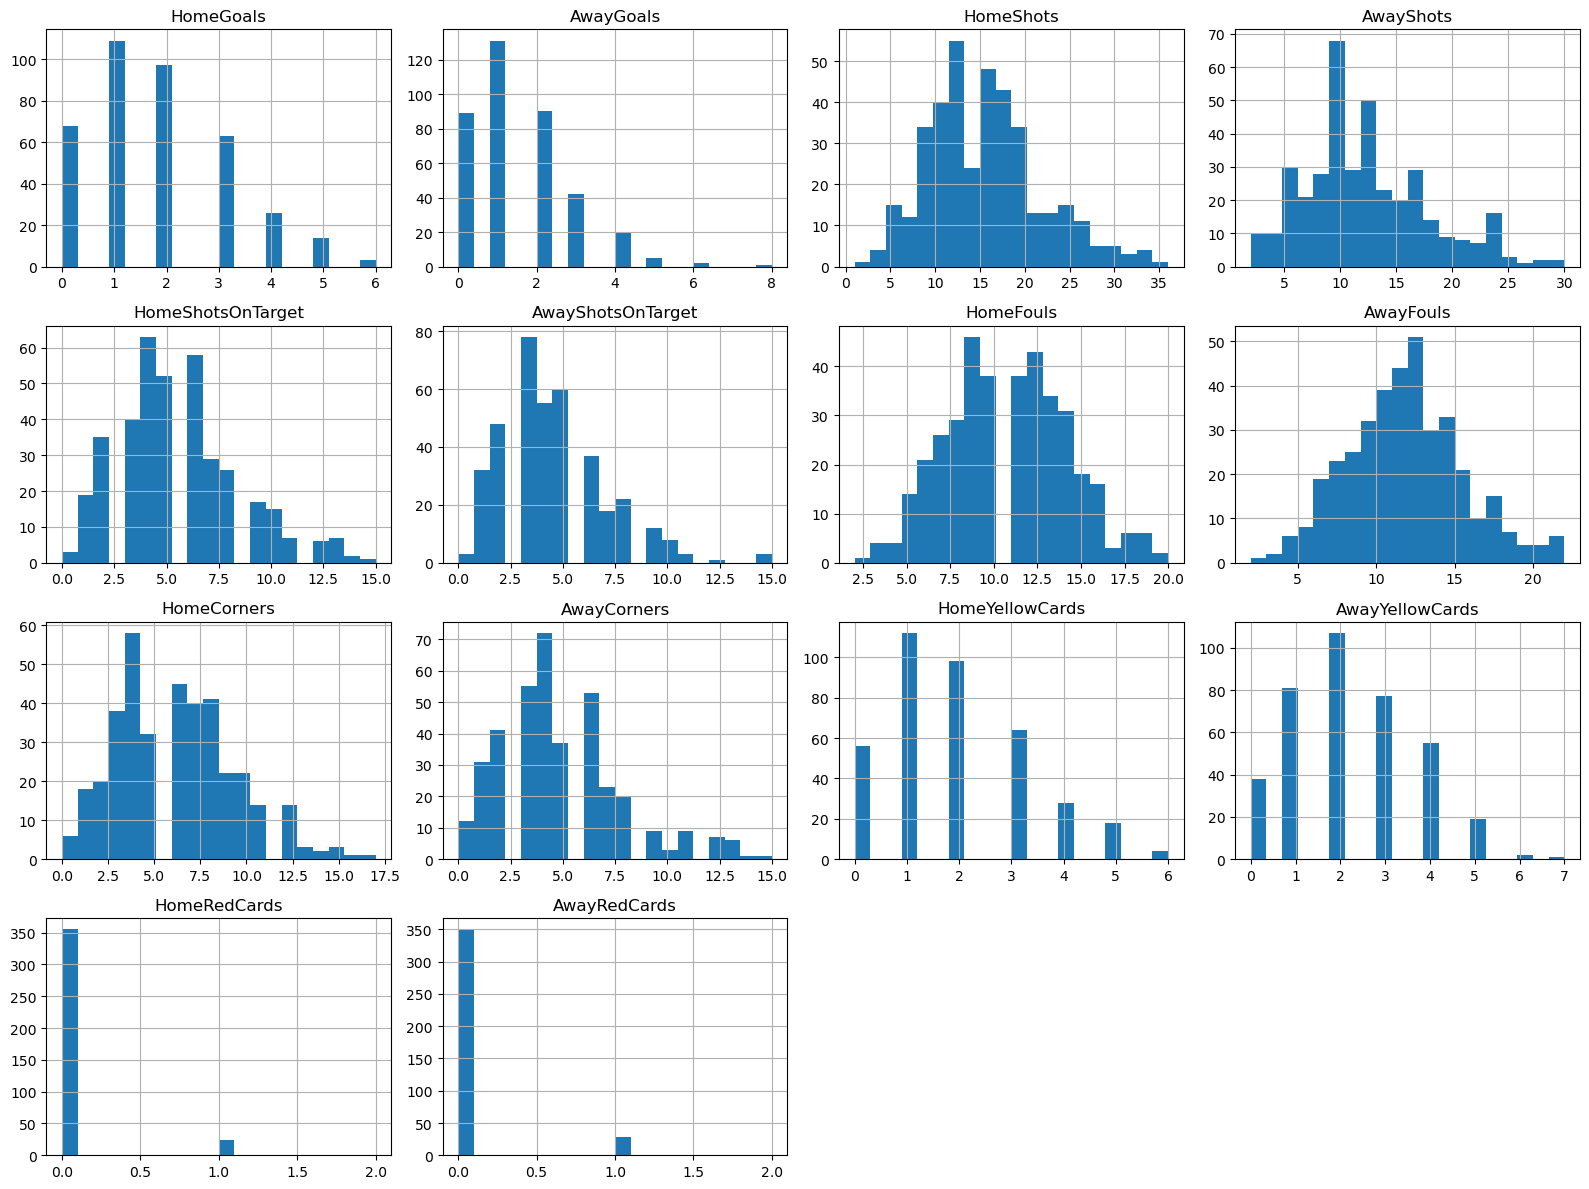

In [9]:
num_cols = ['HomeGoals','AwayGoals','HomeShots','AwayShots',
            'HomeShotsOnTarget','AwayShotsOnTarget','HomeFouls','AwayFouls',
            'HomeCorners','AwayCorners','HomeYellowCards','AwayYellowCards',
            'HomeRedCards','AwayRedCards']

df[num_cols].hist(bins=20, figsize=(16, 12))
plt.tight_layout()
plt.show()

In [10]:
df[num_cols].describe().round(2)

,HomeGoals,AwayGoals,HomeShots,AwayShots,HomeShotsOnTarget,AwayShotsOnTarget,HomeFouls,AwayFouls,HomeCorners,AwayCorners,HomeYellowCards,AwayYellowCards,HomeRedCards,AwayRedCards
count,380.00,380.00,380.00,380.00,380.00,380.00,380.00,380.00,380.00,380.00,380.00,380.00,380.00,380.00
mean,1.80,1.48,15.40,12.18,5.44,4.43,10.74,11.35,6.12,4.71,1.91,2.26,0.07,0.08
std,1.37,1.28,6.26,5.47,2.89,2.53,3.46,3.67,3.22,2.91,1.39,1.39,0.26,0.28
min,0.00,0.00,1.00,2.00,0.00,0.00,2.00,2.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,1.00,1.00,11.00,8.00,3.00,3.00,8.00,9.00,4.00,3.00,1.00,1.00,0.00,0.00
50%,2.00,1.00,15.00,11.00,5.00,4.00,11.00,11.00,6.00,4.00,2.00,2.00,0.00,0.00
75%,3.00,2.00,19.00,15.00,7.00,6.00,13.00,14.00,8.00,6.00,3.00,3.00,0.00,0.00
max,6.00,8.00,36.00,30.00,15.00,15.00,20.00,22.00,17.00,15.00,6.00,7.00,2.00,2.00


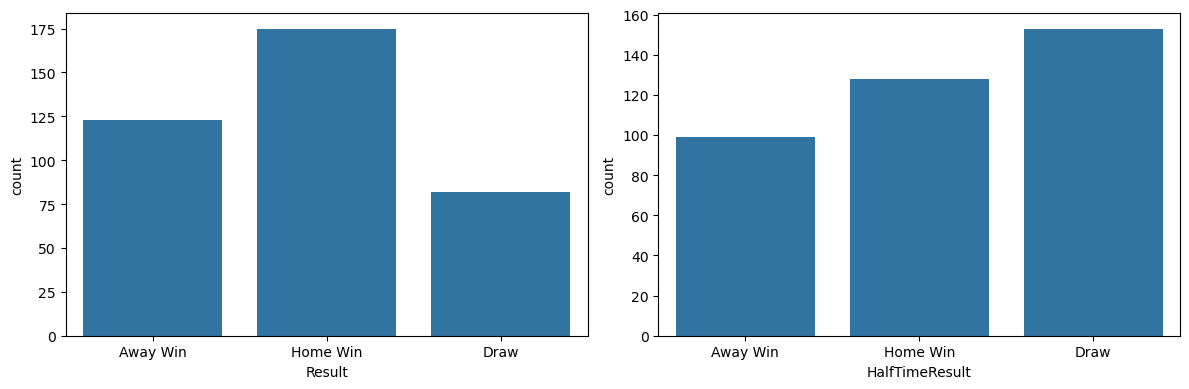

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.countplot(data=df, x='Result', ax=axes[0])
sns.countplot(data=df, x='HalfTimeResult', ax=axes[1])
plt.tight_layout()
plt.show()